# TissueNarrator — spatial QA tutorial

TissueNarrator can be fine-tuned for natural-language spatial reasoning. We compare the
two QA finetunes — **TN-sft** (`v2_tn`, on top of the MERFISH TissueNarrator checkpoint)
and **Base-sft** (`v2_base`, the same finetune from base Qwen) — across 4 spatial-QA tasks:

1. **highly_expressed_genes** — name the top genes of a cell class in a brain region.
2. **spatial_real_vs_fake** — is a spatial neighborhood genuine or tampered?
3. **forward_spatial** (de-pert) — classify a gene as up/down/not-DE near a knockout.
4. **pathway_spatial** (de-pathway) — is a pathway activated in KO-adjacent T cells?

Section 1 reconstructs each task's QA dataset **from the underlying spatial data**;
section 2 plots the model scores (precomputed in `qa_results.csv`).

> **Note.** Building the full QA corpus + training/scoring the QA models takes a GPU and
> external APIs; this notebook reconstructs the task *data* (~10 min, CPU only) and reads
> the precomputed scores. See [`02_train`](02_train.ipynb) / [`03_demo_inference`](03_demo_inference.ipynb)
> for training and inference.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))
import tutorial_utils as tu
from tutorial_utils import data_path
import qa_build as qb
tu.setup_style()
print("ready")

ready


## 1 · Reconstructing the QA task data

Each task turns a piece of spatial ground truth into a (prompt, answer) pair. The
construction logic lives in `qa_build.py` (ported from the production build scripts).

### highly_expressed_genes — top genes per (region, cell class)

In [2]:
import anndata as ad
merfish = ad.read_h5ad(data_path("merfish_preprocessed.h5ad"))
hxg = qb.build_hxg_qa(merfish, region_col="parcellation_structure", min_cells=20)
print(f"{len(hxg)} items over {hxg.region.nunique()} regions x {hxg.cell_class.nunique()} classes\n")
print("PROMPT:\n", hxg.prompt.iloc[0])
print("\nANSWER:\n", hxg.answer.iloc[0])

2292 items over 333 regions x 32 classes

PROMPT:
 List the top 20 highly expressed genes in the Astro-Epen cell class of the AAA region from the mouse brain. Format your answer as a ranked list of gene names separated by commas, for example: <ANSWER>gene1, gene2, ...

ANSWER:
 Mfge8, Gja1, Acsbg1, Gpr37l1, S1pr1, Slc7a10, Ntsr2, Agt, Pou3f3, Grin2c, Fam107a, Aldh1l1, Gprc5b, Itih3, Serpine2, Slc9a3r1, Pla2g7, Sox9, Aqp4, Cxcl14


### spatial_real_vs_fake — real neighborhood vs one with foreign cells inserted

We turn each cell into a ranked gene list, bin cells spatially, then for each bin emit the
real sentence (Yes) and a tampered copy (No) where a few cells are swapped for far-away
cells of the same section. (Run on two sections here for speed.)

In [3]:
secs = merfish.obs["section"].astype(str).value_counts().index[:2].tolist()
sub = merfish[merfish.obs["section"].astype(str).isin(secs)].copy()
cell_df = qb.cell_sentences_from_adata(sub)
rvf = qb.build_real_vs_fake_qa(cell_df)
print(f"{len(rvf)} items | labels: {rvf.answer.value_counts().to_dict()}\n")
print("PROMPT (real example, truncated):\n", rvf[rvf.answer=='Yes'].prompt.iloc[0][:520], "...")
print("\nANSWER:", rvf[rvf.answer=='Yes'].answer.iloc[0])

172 items | labels: {'Yes': 86, 'No': 86}

PROMPT (real example, truncated):
 You are given a spatial neighborhood of tissue from the mouse brain.
Each cell is formatted as:
<pos> X: <int>, Y: <int> <cs> gene1 gene2 ... </cs>
Here, <pos> gives the cell location and <cs> is a ranked list of gene names for that cell.
Decide whether this is a real spatial sentence (no cells inserted from outside the neighborhood).
Answer with exactly one token: Yes or No.

Spatial sentence:
<pos> X: 2027, Y: 6405 <cs> Gfap Aqp4 Gja1 Ntsr2 Cldn5 Pou3f3 Adgrf5 S1pr1 Rorb Acsbg1 Aldh1l1 Padi2 Serpine2 Sema6a Itih5 ...

ANSWER: Yes


### forward_spatial (de-pert) — gene up/down/not-DE near a knockout

For each knockout, compute DE in T cells near KO vs near Control, then ask
the model to classify a gene's direction — with 3 KO + 3 Control cancer-cell expression
profiles as spatial context.

In [4]:
import squidpy as sq
pert = ad.read_h5ad(data_path("pertfish_tumors_test.h5ad"))
pert.obsm["spatial"] = pert.obsm["spatial"] * 0.108
sq.gr.spatial_neighbors(pert, coord_type="generic", radius=30)
PERTS = qb.single_perturbation_labels(pert)   # all single-KO labels (matches production)
de_df, nonde_df = qb.compute_perturb_de(pert, PERTS)
print(f"{len(PERTS)} single-KO labels; DE computed for {de_df.perturbation.nunique()} "
      f"(others skipped: too few neighboring T cells)")
cancer_pool = qb.load_cancer_pool(pd.read_parquet(data_path("pertfish_neighbor.parquet")))
fwd = qb.build_forward_spatial_qa(de_df, nonde_df, cancer_pool)
print(f"{len(fwd)} items | answers: {fwd.answer.value_counts().to_dict()}\n")
print("PROMPT (truncated):\n", fwd.prompt.iloc[0][:680], "...")
print("\nANSWER:", fwd.answer.iloc[0])

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


35 single-KO labels; DE computed for 25 (others skipped: too few neighboring T cells)


267 items | answers: {'upregulated': 98, 'not differentially expressed': 89, 'downregulated': 80}

PROMPT (truncated):
 Perturb-FISH combines MERFISH imaging with local amplification of the gRNA region to decode both genetic perturbations and the transcriptome in their spatial context. The screen below profiled a tumor xenograft in which CRISPR knockouts were applied to the cancer cells. For each knockout, we compare T cells in physical contact with KO cancer cells against T cells in contact with Control cancer cells. A gene is called upregulated if adjusted p < 0.05 and log fold change > 0.15, downregulated if adjusted p < 0.05 and log fold change < -0.15, and not differentially expressed otherwise.

Example expression profiles from 3 cancer cells carrying the CHUK knockout (genes ranked  ...

ANSWER: downregulated


### pathway_spatial (de-pathway) — pathway activation near a knockout

GSEA over the per-knockout DE ranking flags activated (Yes) vs unchanged (No) immune
pathways; the spatial cancer-cell context is appended as above. (Needs network for the
gene-set libraries.)

In [5]:
pw = qb.build_pathway_spatial_qa(de_df, nonde_df, cancer_pool, panel_genes={}, permutation_num=100)
print(f"{len(pw)} items | answers: {pw.answer.value_counts().to_dict()}\n")
if len(pw):
    print("PROMPT (truncated):\n", pw.prompt.iloc[0][:560], "...")
    print("\nANSWER:", pw.answer.iloc[0])

90 items | answers: {'Yes': 45, 'No': 45}

PROMPT (truncated):
 Perturb-FISH combines MERFISH imaging with local amplification of the gRNA region to decode both genetic perturbations and the transcriptome in their spatial context. The screen below profiled a tumor xenograft in which CRISPR knockouts were applied to the cancer cells. For each knockout, we compare T cells in physical contact with KO cancer cells against T cells in contact with Control cancer cells. A pathway is called activated if its members show coordinated positive enrichment in the KO-adjacent T cells (GSEA, FDR < 0.25 with positive normalized enri ...

ANSWER: Yes


## 2 · QA performance — TN-sft vs Base-sft

Per-task scores (overlap@k for gene-list tasks, accuracy for the reasoning tasks),
precomputed in `qa_results.csv`.

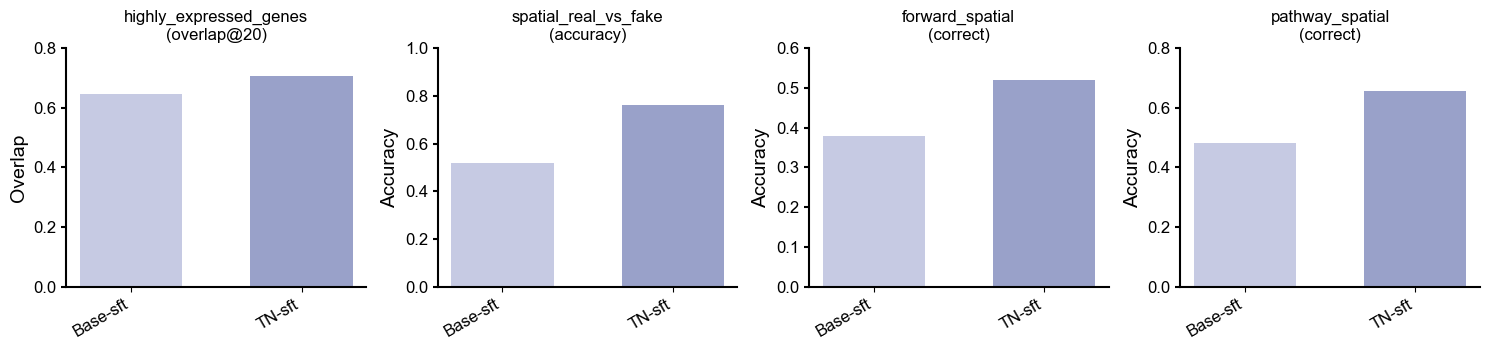

In [6]:
import matplotlib.pyplot as plt
TABLE = pd.read_csv(data_path("qa_results.csv")).set_index("task")
MODELS = ["v2_base", "v2_tn"]
ABBR = {"v2_base": "Base-sft", "v2_tn": "TN-sft"}
COLORS = {"v2_base": "#c6cae3", "v2_tn": "#99a1c9"}
TASKS = [("highly_expressed_genes", "Overlap", (0, 0.8)),
         ("spatial_real_vs_fake",   "Accuracy", (0, 1.0)),
         ("forward_spatial",        "Accuracy", (0, 0.6)),
         ("pathway_spatial",        "Accuracy", (0, 0.8))]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (task, ylabel, ylim) in zip(axes, TASKS):
    vals = TABLE.loc[task, MODELS].astype(float).values
    ax.bar(np.arange(len(MODELS)), vals, width=0.6, color=[COLORS[m] for m in MODELS])
    ax.set_xticks(np.arange(len(MODELS)))
    ax.set_xticklabels([ABBR[m] for m in MODELS], rotation=30, ha="right")
    ax.set_ylabel(ylabel, fontsize=14); ax.set_ylim(*ylim)
    ax.set_title(f"{task}\n({TABLE.loc[task, 'metric']})", fontsize=12)
    for pos in ("top", "right"): ax.spines[pos].set_visible(False)
    ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="y", labelsize=12, width=1.5); ax.tick_params(axis="x", labelsize=12)
plt.tight_layout(); plt.show()